# $ \text{Video Killed The Radio Star}$ $\color{red}{...Diffusion}$



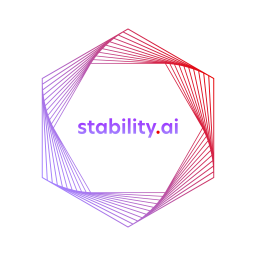

Notebook by David Marx ([@DigThatData](https://twitter.com/digthatdata))

Shared under MIT license

Last updated: 2023-06-15

Latest stable notebook revision: [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/dmarx/video-killed-the-radio-star/blob/main/Video_Killed_The_Radio_Star_Defusion.ipynb)

# Introduction

VKTRS is a tool for planning and generating complex animations using audio with spoken/sung words as conditioning input. The planning work can be used independently from generating an animation: all of your work is saved to a human-readable and modifiable `storyboard.yaml` file. Parameter names and notation are also compatible with other AI animation tools, such as a1111-deforum.

The inspiration for this notebook and the "variations" animation modes were  [this video](https://www.youtube.com/watch?v=WJaxFbdjm8c) created by Ben Gillin.

# General Workflow

If you are reading this in colab, open the "Table of contents" tab on the left sidebar for a more detailed enumeration of the steps described below.

1. Pick an audio source, like a youtube video
2. The notebook will download the video if necessary
3. OpenAI's "whisper" model is used to transcribe the lyrics
4. The timing of this transcription is used to segment the timeline into a sequence of "scenes"
5. The musical structure of the audio is analyzed to group thematically similar themes
6. Scene/theme specific settings (prompts, camera motion) can then be added
7. The audio can be further processed to isolate signals for driving animation parameters for "audioreactive" effects. This includes isolating instruments (demucs) and chaining manipulations (librosa)
8. Generate or specify starting images for each scene
9. Generate the remaining frames to animate each scene

**NB: the `img2img` animation mode is currently only supported when using the stability ai animation api (DreamStudio) to generate animations**. The audioreactivity features are currently only relevant in img2img mode. If you don't have a DreamStudio account, you can still use this notebook to parameterize an animation, you'll just need to cut-and-paste settings out of the "export settings" cell (deforum compatible) or the `storyboard.yaml` file.

# The "Storyboard"

Start at the top of the notebook and work your way down. Each decision you make contributes information to a file called "the storyboard", which persists project state. The notebook is designed to facilitate working iteratively: once you've made it past a given decision point, you should generally be able to jump back to that point to tweak whatever the decision was and return to where you were.

The storyboard isn't just a logical abstraction, it's a physical file you can modify directly, and is reasonably human readable.

Every project you start will create a new storyboard. If you set your project name to one you used previously, the notebook will attempt to find that project and load its storyboard.

The original motivation behind VKTRS was to be a toy for automating generative music videos. It has evolved quite a bit since, and I now mostly think about it as a tool for building and manipulating these storyboards. The storyboard parameterizes an animation, but the actual animation doesn't need to be generated by this tool.


# $\text{FAQ}$

**Why the name?**

The notebook's name is an ironic homage to the first music video played on MTV: [The Bugles - Video Killed The Radio Star](https://www.youtube.com/watch?v=W8r-tXRLazs). Quoting [wikipedia](https://en.wikipedia.org/wiki/Video_Killed_the_Radio_Star):

> "The song relates to concerns about, and mixed attitudes toward 20th-century inventions and machines for the media arts."

**Something didn't work quite right in the transcription process. How do fix the timing or the actual lyrics?**

The notebook is divided into several steps. Between each step, a "storyboard" file is updated. If you want to
make modifications, you can edit this file directly and those edits should be reflected when you next load the
file. Depending on what you changed and what step you run next, your changes may be ignored or even overwritten.
Still playing with different solutions here.

**Can I provide my own images to 'bring to life' and associate with certain lyrics/sequences?**

Yes, you can! As described above: you just need to modify the storyboard. Will describe this functionality in
greater detail after the implementation stabilizes a bit more.

**How can I support your work or work like it?**

This notebook was made possible thanks to ongoing support from [stability.ai](https://stability.ai/). The best way to support my work is to share it with your friends, [report bugs](https://github.com/dmarx/video-killed-the-radio-star/issues/new), [suggest features](https://github.com/dmarx/video-killed-the-radio-star/discussions) or to donate to open source non-profits :)

# Examples of content made with VKTRS

[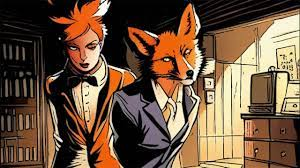](https://www.youtube.com/watch?v=dx8LmqalrmU)

**The Sudden - Fine (Official Music Video)** `variations` animation mode and theme prompts.

<div><a href="https://www.youtube.com/watch?v=ScbXSLYyzq4"><img src="https://i.ytimg.com/vi_webp/ScbXSLYyzq4/oar2.webp" alt="Hi-Standard - Asian Pride" width="300"/></a></div>

 **Hi-Standard - Asian Pride** `img2img` animation mode (via the Stability.AI animation API), with camera movement and simple audioreactivity (vocals stem driving `strength_curve` and `noise_curve`). This was one of my test animations and doesn't do the notebook justice, but you'll get the idea.



## $0.$ Setup

In [ ]:
# @title # 📊 Check GPU Status

import io
import pandas as pd
import subprocess

def gpu_info(timeout: int = 5) -> pd.DataFrame:
    """Return GPU info from nvidia-smi as a DataFrame.

    Handles missing nvidia-smi, timeouts, and multiple GPUs gracefully.
    """
    try:
        result = subprocess.run(
            [
                "nvidia-smi",
                "--query-gpu=timestamp,name,utilization.gpu,utilization.memory,memory.used,memory.free",
                "--format=csv",
            ],
            capture_output=True,
            text=True,
            timeout=timeout,
            check=False,
        )
    except FileNotFoundError:
        return pd.DataFrame()
    except subprocess.TimeoutExpired:
        return pd.DataFrame()

    if result.returncode != 0 or not result.stdout:
        return pd.DataFrame()

    try:
        df = pd.read_csv(io.StringIO(result.stdout))
    except (pd.errors.EmptyDataError, pd.errors.ParserError):
        return pd.DataFrame()

    df.columns = [col.replace(".", " ").strip().title() for col in df.columns]
    return df

gpu_info()

In [ ]:
#%%capture

# @title # 🛠️ Setup: Install Dependencies

import importlib.util


def is_colab() -> bool:
    """Detect if running inside Google Colab."""
    return importlib.util.find_spec("google.colab") is not None


local = not is_colab()

# Install pinned dependencies from repository requirement files
# (GPU extras are isolated in requirements-gpu.txt)
if local:
    %pip install -r requirements.txt -r requirements-gpu.txt
else:
    %pip install -r requirements.txt
    %pip install -r requirements-gpu.txt


In [ ]:
def trivial_subsegmentation(segment, threshold=0, gaps=None):
    """
    split on gaps in detected vocal activity.
    Contiguity = gap between adjacent tokens is less than the input threshold.
    """
    if gaps is None:
        gaps = calculate_interword_gaps(segment)
    out_segments = []
    this_segment = [segment['words'][0]]
    for word, preceding_pause in zip(segment['words'][1:], gaps):
        if preceding_pause <= threshold:
            this_segment.append(word)
        else:
            out_segments.append(this_segment)
            this_segment = [word]
    out_segments.append(this_segment)

    outv = [dict(
        start=seg[0]['start'],
        end=seg[-1]['end'],
        text=''.join([w['word'] for w in seg]).strip(),
    ) for seg in out_segments]

    return outv


## 1. 📋💬 Build Base Storyboard
* Initial setup
* Infer keyframes for scene segmentation

In [ ]:
# @title ### 📋 Attach Storyboard (create or resume project)

project_name = '' # @param {type:'string'}

# TODO: make it so I can change this value without restarting the kernel....
use_stability_api = False # @param {type:'boolean'}
mount_gdrive = True # @param {type:'boolean'}
resume=True # @param {type:'boolean'}

# TODO: add support for whisper API

# @markdown Enter a unique `project_name`.
# @markdown If left blank, the current unix timestamp will be used
# @markdown  (seconds since 1970-01-01 00:00).

# @markdown If you use the name of an existing project, the workspace will switch to that project (even if `resume` is unchecked. Each project needs a unique name).

# @markdown Non-alphanumeric characters (excluding '-' and '_') will be replaced with hyphens.

# @markdown ---

# @markdown # Detailed Discussion
# @markdown In VKTRS, a "project" is encapsulated by a folder.
# @markdown With google drive loaded, it will be the `<project_name>` subfolder under the path:
# @markdown `/content/drive/MyDrive/AI/VideoKilledTheRadioStar/`

# @markdown ---

# @markdown Depending on your settings and environment, running this cell may prompt you to enter one or more API Keys below.
# @markdown Don't forget to press "enter" after providing a requested key.


##########################

try:
    local=False
except:
    local=True

if local:
    mount_gdrive=False


##################################################################

resuming = False
if resume:
    try:
        workspace, storyboard = load_storyboard()
        print("loading storyboard")
        resuming=True
    except:
        resuming = False

if not resuming:
    if not project_name:
        project_name = str(time.time())
    project_name = sanitize_folder_name(project_name)

    print("creating workspace")

    workspace = establish_workspace(
        use_stability_api=use_stability_api,
        mount_gdrive=mount_gdrive,
        application_name="VideoKilledTheRadioStar",
        active_project=project_name,
    )

    print("creating new storyboard")
    storyboard = OmegaConf.create()
    storyboard.params = {}
    storyboard.prompt_starts=[]


# f.
workspace.use_stability_api = use_stability_api
with open('config.yaml','w') as fp:
    OmegaConf.save(config=workspace, f=fp.name)

#if workspace.use_stability_api:
if use_stability_api:

    import os
    import getpass
    if not os.environ.get('STABILITY_KEY'):
        os.environ['STABILITY_KEY'] = getpass.getpass('Enter your Stability API Key, then press enter to continue')


    # @markdown To get your API key visit https://dreamstudio.ai/account
    STABILITY_HOST = "grpc.stability.ai:443" #@param {type:"string"}



    ###################################

    STABILITY_KEY = os.environ.get('STABILITY_KEY')

    # Connect to Stability API
    context = Context(STABILITY_HOST, STABILITY_KEY)

    # Test the connection
    context.get_user_info()



else:
    # TODO: check for HF token in environment
    if not local:
        from google.colab import output
        output.enable_custom_widget_manager()

    from huggingface_hub import notebook_login
    notebook_login()

##################################################################

root = Path(workspace.project_root)

assets_dir = Path(workspace.shared_assets_root)

video_assets_meta_fname = assets_dir / 'video_assets_meta.yaml'
audio_assets_meta_fname = assets_dir / 'audio_assets_meta.yaml'

video_assets_meta = OmegaConf.load( assets_dir/'video_assets_meta.yaml' )
audio_assets_meta = OmegaConf.load( assets_dir/'audio_assets_meta.yaml' )

# just to be safe
save_storyboard(storyboard)
workspace, storyboard = load_storyboard()

rich.print(dict(workspace))

In [ ]:
# @title ⬇ Set Audio Source

d_ = dict(
    # all the underscore does is make it so each of the following lines can be preceded with a comma
    # otw the first parameter would be offset from the other in the colab form
    _=""

    , video_url = 'https://www.youtube.com/watch?v=REojIUxX4rw' # @param {type:'string'}
    , audio_fpath = '' # @param {type:'string'}
)
d_.pop('_')

# @markdown `video_url` - URL of a youtube video to download as a source for audio and potentially for text transcription as well.

# @markdown `audio_fpath` - Optionally provide an audio file instead of relying on a youtube download. Name it something other than 'audio.mp3',
# @markdown                 otherwise it might get overwritten accidentally.


storyboard.params = d_

storyboard_fname = root / 'storyboard.yaml'
with open(storyboard_fname,'wb') as fp:
    OmegaConf.save(config=storyboard, f=fp.name)


###############################
# Download audio from youtube #
###############################

# this should modify the existing record for the URL rather than creating a new one...
force_redownload=False

video_url = storyboard.params.video_url
download_video=True

if not force_redownload:
    for rec in video_assets_meta.videos:
        if rec.video_url == video_url:
            if rec.get('video_fpath'):
                print("previously downloaded video detected")
                download_video=False
                # populate storyboard with previous processing results
                if rec.get('audio_fpath'):
                    storyboard.params.audio_fpath = rec.get('audio_fpath')
            else:
                download_video=True # should be redundant?
            break



if download_video:
    # check if user provided an audio filepath (or we already have one from youtube) before attempting to download
    video_assets_meta_record = {}
    video_assets_meta_record['video_url'] = video_url

    ytdl_prefix = "DOWNLOADED__"
    ytdl_fname = f"{str(assets_dir / ytdl_prefix)}%(title)s.%(ext)s"

    !yt-dlp -o "{ytdl_fname}" {video_url}

    matched_files = assets_dir.glob(ytdl_prefix+"*")
    most_recent_file = max(matched_files, key=os.path.getctime)
    print(f"downloaded: {most_recent_file}")
    ytdl_fname = most_recent_file

    video_assets_meta_record['video_fpath'] = str(ytdl_fname.absolute())

    # TODO: right here, we should be adding this to the audio meta
    audio_fpath = ytdl_fname.with_suffix('.m4a')
    input_audio = ytdl_fname
    !ffmpeg -y -i "{input_audio}" -vn -c:a aac "{audio_fpath}"

    storyboard.params.audio_fpath = audio_fpath
    video_assets_meta_record['audio_fpath'] = str(audio_fpath.absolute())

    video_assets_meta.videos.append(video_assets_meta_record)


save_storyboard(storyboard)

with open(video_assets_meta_fname, 'wb') as fp:
    OmegaConf.save(config=video_assets_meta, f=fp.name)



In [ ]:
# @title ### 🔊 Initial Audio Processing

# @markdown * Transcribe and segment speech using whisper

# @markdown * Analyze major musical structure

# @markdown If this audio source has been previoussly processed by this notebook, that should be detected and processing won't be repeated.

##################################################
# 💬 Transcribe and segment speech using whisper #
##################################################

audio_fpath = str(storyboard.params.audio_fpath)

separate_stems = False # @param {type:'boolean'}

# these are just confusing i think
force_retranscription = False # #@#param {type:'boolean'}
override_storyboard_transcription = False # #@#param {type:'boolean'}

whisper_seg = None

if audio_fpath in audio_assets_meta:
    print("previously processed audio detected")
    audio_meta = audio_assets_meta[audio_fpath]
else:
    audio_assets_meta[audio_fpath] = {}
    audio_meta = audio_assets_meta[audio_fpath]

if (not force_retranscription) and audio_meta.get('whisper_segmentation') and Path(audio_meta.whisper_segmentation).exists():
    print("Using pre-existing whisper transcription")
    whisper_seg_fpath = Path(audio_meta.whisper_segmentation)
    with whisper_seg_fpath.open() as f:
        timings = json.load(f)
    whisper_seg = timings['segments']


if force_retranscription or (whisper_seg is None):
    print("Transcribing...")
    #audio_meta['audio_fpath'] = storyboard.params.audio_fpath redundant
    # outputs text files as audio.* locally
    !whisper --model large --word_timestamps True -o {str(assets_dir)} "{storyboard.params.audio_fpath}"

    whisper_seg_fpath = Path(storyboard.params.audio_fpath).with_suffix('.json')
    audio_meta['whisper_segmentation'] = str(whisper_seg_fpath)
    audio_meta['duration'] = get_audio_duration_seconds(audio_fpath)

    with whisper_seg_fpath.open() as f:
        timings = json.load(f)
    whisper_seg = timings['segments']

    audio_assets_meta[audio_fpath] = audio_meta
    with open(audio_assets_meta_fname, 'wb') as fp:
        OmegaConf.save(config=audio_assets_meta, f=fp.name)

if not storyboard.get('prompt_starts') or override_storyboard_transcription:

    # Ta da!
    storyboard.prompt_starts = [{k:rec[k] for k in ('start','end','text')} for rec in whisper_seg]

    storyboard.params['video_duration'] = audio_meta['duration']
    # unsure if below method is reliable.
    #storyboard.params['video_duration'] = storyboard.prompt_starts[-1]['end']


# TODO: enforce scene zero starts at t=0 and last scene ends at duration

#storyboard.prompt_starts = prompt_starts
save_storyboard(storyboard)

# Music Structure Analysis

# Music Structure Analysis
# - beat and tempo detection
# - Self-similarity graph

audio_structure_features = analyze_audio_structure(audio_fpath=storyboard.params.audio_fpath)

audio_features_fpath = Path(storyboard.params.audio_fpath).with_suffix('.audio_features.safetensors')
save_safetensors(audio_structure_features, audio_features_fpath)

# TODO: fix inconsistent variable naming
structural_features = audio_structure_features

# TODO: un-"PosixPath" `storyboard.params.audio_fpath`
# TODO: this is a confusing af way to access this.
audio_assets_meta[str(storyboard.params.audio_fpath)]['structural_features'] = audio_features_fpath


with open(audio_assets_meta_fname, 'wb') as fp:
    OmegaConf.save(config=audio_assets_meta, f=fp.name)

if separate_stems:
    ensure_stems_separated()

# TODO: ~PLACEHOLDER~ Give user opportunity to correct the transcription at shared_asset level rather than project


In [ ]:
# @title ### 🎞️ Show Current Storyboard
workspace, storyboard = load_storyboard() # just to ensure consistency
show_storyboard()

In [ ]:
# @title ### ✂️ Subdivide Unusually Long Scenes

# @markdown Attempts to identify unusually long scenes and splits them into multiple shorter scenes.
# @markdown Estimates the expected scene duration to identify outliers.

# TODO: wrap these steps in functions for legibility/portability
# TODO: make this threshold parameterizable via storyboard (and save analysis to storyboard)
# TODO: use beat counts to estimate a smart scene duration

subdivide_long_scenes = True # @param {'type':'boolean'}

#TODO: merge short scenes

# TODO: expose this to colab
threshold_duration = None

######################################################
# estimate parameters of scene duration distribution #
######################################################

# TODO: use beat onsets/counts
scene_durations = []
scenes_ = []
for idx, rec in enumerate(storyboard.prompt_starts):
    rec=dict(rec)
    if idx > 0:
        # are we maybe doubling up 'start' time stamps? like there are more unique 'end's than 'start's?
        duration = rec['start'] - prev['start']
        prev['duration_'] = duration
        scene_durations.append(duration)
    prev = rec
    scenes_.append(prev)

# handle last record
else:
    duration = rec['end'] - rec['start']
    rec['duration_'] = duration
    scenes_.append(rec)
    scene_durations.append(duration)

# handle case where there's only one scene
if idx == 0:
    duration = rec['end'] - rec['start']
    rec['duration_'] = duration
    scenes_.append(rec)
    scene_durations.append(duration)

mu = sum(scene_durations)/len(scene_durations)
sigma = np.std(scene_durations)

# 1sd filter to concentrate on mode
scene_durations2 = [s for s in scene_durations if (mu - sigma) < s < (mu+sigma)]
try:
    mu2 = sum(scene_durations2)/len(scene_durations2)
    sigma2 = np.std(scene_durations2)
    if mu2==0:
        subdivide_long_scenes=False
except ZeroDivisionError:
    subdivide_long_scenes = False
    warnings.warn(
        "Sorry, you've hit an unsupported edge case. "
        "We need some sort of segmentation to start with, but right now "
        "our initial heuristics have everything in one long scene. "
        "If you're trying to animate an instrumental track, VKTRS "
        "doesn't intelligent scene segmentation for that use case yet. "
        "Scene segmentation needs lyrics at the moment."
    )

###########

# break up "outlier" segments into smaller chunks
# this heuristic could be improved with beat synchronization and onset detection.
# ... also could probably leverage the 'end' time of the scene
# TODO: hierarchical theme structure analysis
# TODO: MSA segmentation for fully instrumental (i.e. arbitrary) audio

if subdivide_long_scenes:

    threshhold = mu2 + sigma
    if threshold_duration is not None:
        threshhold = threshold_duration

    scenes = []
    #for rec in storyboard.prompt_starts:
    for rec in list(scenes_):
        gap_remaining = rec['duration_']
        while gap_remaining > threshhold:
            #step = min(max(mu2-sigma, (np.random.normal() + mu2)*sigma), mu2+sigma)
            step=mu2
            step = float(step)
            # TODO: move duration computation somewhere that it will happen necessarily
            rec['duration_'] = step
            new_rec = copy.deepcopy(rec)
            new_rec['start'] = rec['start'] + step
            # TODO: deal with new value here
            #new_rec['end'] = ??
            new_rec['duration_'] = step
            ### maybe i could add a flag or something to clarify that this was an "inferred" subscene
            #new_rec['parent_scene'] = rec.get('uid') # something like this?
            new_rec['inferred_subscene'] = True # or this?

            scenes.append(rec)
            rec = new_rec
            gap_remaining -= step
        scenes.append(rec)

    storyboard.prompt_starts = scenes

# TODO: get last scene "end" from story duration

# TODO: compute duration regardless of extra segmentation

# TODO: add scene indices back to rec's to facilitate editing the text file

save_storyboard(storyboard)
show_storyboard(storyboard)

In [ ]:
# fallback if infer_thematic_structure is False
for idx, rec in enumerate(storyboard.prompt_starts):
    rec['_theme'] = themes[idx % len(themes)]


## $2.$ 🎥🌈 Define your animation's aesthetics

### 2.1 📋 Assign Themes to Scenes

In [ ]:


# @markdown `theme_prompt` - Text that will be appended to the end of each lyric, useful for e.g. applying a consistent aesthetic style.
# @markdown  To provide multiple themes (only one will be used per scene), separate theme prompts with the `|` (pipe) symbol.

# @markdown `infer_thematic_structure` - if False, themes will be rotated sequentially such that no two adjacent frames
# @markdown will use the same theme prompt (if multiple theme prompts were provided). If True, song structure analysis will cluster related scenes into as many groups as there are theme prompts to attempt to associate a visual themes with respective musical themes.

# @markdown The analysis runs quick. If you didn't understand that explanation, just try it both ways and you'll probably get the idea.

theme_prompt = 'zombie wedding | zombie dance party | zombies in love' # @param {type:'string'}

infer_thematic_structure = True # @param {type:'boolean'}

storyboard.params.theme_prompt = theme_prompt
themes = [prompt.strip() for prompt in theme_prompt.split('|') if prompt.strip()]

# communicate theme_id mappings
df_themes = pd.DataFrame({'theme prompt':themes})
df_themes.index.name="theme_id"

rich.print(df_themes)
print()

if (len(themes) > 1):
    if infer_thematic_structure:

        # audio_assets_meta[storyboard.params.audio_fpath]['structural_features']
        beat_times = audio_structure_features['beat_times']
        evecs = audio_structure_features['evecs']
        segment_labels = laplacian_segmentation(
            evecs=evecs,

            # TODO: publish these parameters to the user
            n_clusters=len(themes), # be sure to explain this is an upper bound, stochastic
            n_spectral_features=len(themes),
        )

        # beatsynch scene start times

        # TODO: swap out rec['end'] -> rec_prev['start'] here
        for rec in storyboard.prompt_starts:
            beat_indices = np.where((beat_times >= rec['start']) & (beat_times <= rec['end']))[0]
            segments_this_interval = segment_labels[beat_indices]
            if len(segments_this_interval) == 0:
                dominant_label = 0
            else:
                dominant_label = int(np.argmax(np.bincount(segments_this_interval)))
            rec['structural_segmentation_label'] = dominant_label
            rec['_theme'] = themes[dominant_label]
    else:
        for rec in storyboard.prompt_starts:
            rec['_theme'] = themes[idx % len(themes)]
else:
    for rec in storyboard.prompt_starts:
        rec['_theme'] = theme_prompt


save_storyboard(storyboard)

# TODO: show dataframe if no init images?
show_storyboard(storyboard)

In [ ]:
# @title #### 📝 (Optional) modify theme prompt without impacting structure label assignments

# @markdown Themes will be assigned to the `structural_segmentation` label that maps to their ordering
# @markdown in the theme prompt. To change which theme goes where, simply modify the order in which
# @markdown they appear in your prompt.

# @markdown **Why the second cell?** The procedure that assigns labels to themes
# @markdown has some randomness, so re-running the cell above with the same
# @markdown settings might produce a different order (i.e. a different theme-label assignment)

theme_prompt = 'rusted industrial machinery | kaiju robot CGI | paperclips! paperclips! |  robotics for beginners | rusted industrial machinery' # @param {type:'string'}

#####################################################

storyboard.params.theme_prompt = theme_prompt
themes = [prompt.strip() for prompt in theme_prompt.split('|') if prompt.strip()]

for rec in storyboard.prompt_starts:
    theme_idx = rec.get('structural_segmentation_label',0)
    rec['_theme'] = themes[theme_idx]

save_storyboard(storyboard)
show_storyboard(storyboard)

### 2.2 🎛️🎚️ Animation Settings

In [ ]:
# @title #### 🎚️ (Advanced) `img2img` Animation settings

# @markdown NB: Skip this cell if you're not using the `img2img` animation mode. Go directly to the next cell, "📌".

# TODO: let's move `variations` settings into their own dedicated area,
#       call this "`img2img` animation settings" or something like that instead

# @markdown Run This cell to reveal a multi-tab UI for specifying `img2img` animation settings. When you are happy with your settings,
# @markdown run the cell which follows this one to attach the settings you have selected to one or more scenes/themes.

# @markdown To reset values to default, simply re-run this cell.

# @markdown The `img2img` animation mode is currently only supported through the Stability.AI Animation API (i.e. DreamStudio API).
# @markdown The `img2img` animation parameters are mostly compatible with deforum: if you don't want to animate via the Stability.AI,
# @markdown you can still use this notebook to configure your animation and then port the relevant settings from the `storyboard.yaml`
# @markdown to your tool of choice.

if not workspace.use_stability_api:
    warnings.warn("img2img animation currently only supported if you're using the stability API")
    arg_objs=[]
else:


    show_documentation = True # @param {type:'boolean'}
    # TODO: Move/add context to setup cell, and/or generation cells


    ###################

    args_generation = BasicSettings()
    args_animation = AnimationSettings()
    args_camera = CameraSettings()
    args_coherence = CoherenceSettings()
    args_color = ColorSettings()
    args_depth = DepthSettings()
    args_render_3d = Rendering3dSettings()
    args_inpaint = InpaintingSettings()
    args_vid_in = VideoInputSettings()
    args_vid_out = VideoOutputSettings()
    arg_objs = (
        args_generation,
        args_animation,
        args_camera,
        args_coherence,
        args_color,
        args_depth,
        args_render_3d,
        args_inpaint,
        args_vid_in,
        args_vid_out,
    )

    def _show_docs(component):
        cols = []
        for k, v in component.param.objects().items():
            if k == 'name':
                continue
            col = pn.Column(v, v.doc)
            cols.append(col)
        return pn.Column(*cols)

    def build(component):
        if show_documentation:
            component = _show_docs(component)
        return pn.Row(component, width=1000)

pn.extension()

pn.Tabs(*[(a.name[:-5], build(a)) for a in arg_objs])

### 2.3 📌 Attach settings to scenes

In [ ]:
def compile_storyboard(storyboard, override_signals=None, override_storyboard=False):
    compiled_storyboard = []
    overrides = override_signals if override_signals else {}
    story_defaults = storyboard.get('animation_args', {})

    for rec in storyboard.prompt_starts:
        # start with defaults unless explicitly ignored
        if override_storyboard:
            scene_args = {}
        else:
            scene_args = OmegaConf.to_container(story_defaults, resolve=True) if story_defaults else {}

        # merge per-scene overrides
        scene_args.update(OmegaConf.to_container(rec.get('animation_args', {}), resolve=True) if rec.get('animation_args') else {})

        # apply runtime overrides
        scene_args.update(overrides)

        rec['animation_args'] = scene_args
        compiled_storyboard.append(rec)

    return compiled_storyboard


In [ ]:
# @title ### 🎞️ Show Current Storyboard
workspace, storyboard = load_storyboard() # just to ensure consistency
show_storyboard()

# Normalize audio_assets_meta to dict keyed by audio_fpath
if isinstance(audio_assets_meta, list):
    audio_assets_meta = {rec.get('audio_fpath'): rec for rec in audio_assets_meta if rec.get('audio_fpath')}
elif hasattr(audio_assets_meta, 'content'):
    content = audio_assets_meta.content
    if isinstance(content, list):
        audio_assets_meta = {rec.get('audio_fpath'): rec for rec in content if rec.get('audio_fpath')}

# Ensure dict exists
if not isinstance(audio_assets_meta, dict):
    audio_assets_meta = {}

# ... later when saving
if audio_assets_meta_fname:
    serializable_audio_meta = list(audio_assets_meta.values())
    OmegaConf.save(OmegaConf.create({'content': serializable_audio_meta}), audio_assets_meta_fname)


In [ ]:
def apply_themes_to_scenes(storyboard, scene_ids, theme_ids, override_storyboard=False):
    applicable_scenes = set(scene_ids)

    # Resolve theme_ids to scene indices matching structural_segmentation_label
    if theme_ids:
        for idx, rec in enumerate(storyboard.prompt_starts):
            if rec.get('structural_segmentation_label') in theme_ids:
                applicable_scenes.add(idx)

    for idx, rec in enumerate(storyboard.prompt_starts):
        if idx not in applicable_scenes:
            continue

        board_args = rec.get('animation_args')
        if board_args:
            board_args = OmegaConf.to_container(board_args, resolve=True)
        else:
            board_args = {}

        new_args = collect_animation_args(rec)
        if not override_storyboard and isinstance(board_args, dict):
            new_args.update(board_args)

        rec['animation_args'] = new_args

    return storyboard


#### Manipulate the signal

In [ ]:
def sqrt(y, sr):
    return np.sqrt(y)


def normalize(y, sr):
    normalized_signal = y / np.max(np.abs(y)) if np.max(np.abs(y)) != 0 else y
    denom = np.max(normalized_signal)
    if denom == 0:
        return normalized_signal
    return normalized_signal / denom


#### Name and save the new driving signal so you can use it in the storyboard

In [ ]:
# @markdown When you're satisfied with the transformed signal,
# @markdown give it a unique name to make it available to the storyboard.

_, storyboard = load_storyboard()


#import keyframed as kf


use_massaged_signal = True # @param {'type':'boolean'}

driving_signal = driving_signal_massaged if use_massaged_signal else raw_driving_signal

signal_name = 'noise_reactive' # @param {'type':'string'}

### Uncomment this snippet to write your driving signal to an audio file
#import soundfile
#soundfile.write('driving_signal.wav', driving_signal, sr)


if show_spec: # TODO: need a better way to handle this
    frame_time = librosa.samples_to_time(np.arange(len(driving_signal)), sr=sr)
else:
    frame_time = librosa.frames_to_time(np.arange(len(driving_signal)), sr=sr)

driving_signal_kf = kf.Curve({t:v for t,v in zip(frame_time, driving_signal)}, label=signal_name)



# TODO: probably functionality to port to keyframed here

# fix bug from numpy dtypes
for rec in driving_signal_kf._data.values():
    rec.value = float(rec.value)
    rec.t = float(rec.t)
# fucking kill me...
driving_signal_kf._duration = float(driving_signal_kf.duration)


d_signal = driving_signal_kf.to_dict(simplify=False, for_yaml=True)

# TODO: parameter group?
if not storyboard.get('signals'):
    storyboard.signals = {}

storyboard.signals[signal_name] = d_signal

save_storyboard(storyboard)


print("ALL SIGNALS REGISTERED TO STORYBOARD:")

for sig_name, sig_curve in storyboard.signals.items():
    sig_curve = OmegaConf.to_container(sig_curve) # zomg...
    curve = load_curve(sig_curve)

    curve.plot()
    plt.xlabel('seconds')
    plt.ylabel('intensity')
    plt.title(f"{signal_name}")
    full_width_plot()

    # need to convert this from time domain to frame_indx before we can report it out
    #curve_str = ','.join([f"{k:.04f}:({driving_signal_kf[k]:.04f})" for k in driving_signal_kf.keyframes])
    #print(curve_str)


#### 3. Map the signals to parameters

In [ ]:

# @markdown Specify what parameters we want to be driven by these signals and how

# @markdown * `target_parameter` - The animation parameter whose values this will be overriding
# @markdown * `parameter_value` - The an expression defining the value the parameter should take. probably something like `my_named_signal[t]`
# @markdown   * Supports math functions (`sin`, `sum`, etc) and numpy functions (use `np` prefix)
# @markdown   * Supports the following dynamic variables:
# @markdown     * `t` - seconds since beginning of scene
# @markdown     * `theme_id` - maps to a particular theme, reference "Assign Themes to Scenes" to figure out theme_id correspondences
# @markdown     * `scene_id` - scenes since start of story
# @markdown     * `frame_id` - frames since start of current scene

# @markdown If you want to change the scale of the driving signal you can either do the math directly in the `parameter_value` field, or you can use the following fields to make your life slightly easier.

# @markdown * `attr_hi` - The highest value the parameter will take
# @markdown * `attr_low` - The lowest value the parameter will take
# @markdown * `inverse_relationship` - Whether or not the target parameter should be high when the signal is high, or if when the driving signal is high, the driving parameter should be low.
# @markdown  * e.g. If your target is `strength_curve` you probably want an inverse relationship



signal_map =dict(
_=""
    ,target_parameter='noise_add_curve' # @param {'type':'string'}

    ,parameter_value="noise_reactive[t]*(.06-.03) + .03" # @param {'type':'string'}
    ,param_max=1 # @param {'type':'number'}
    ,param_min=0 # @param {'type':'number'}
    ,invert_relationship_to_signal=False
)
signal_map.pop('_')

#############################################################

signal_mappings = {signal_map.pop('target_parameter') : signal_map}
curr_signal_mappings = storyboard.get('signal_mappings', defaultdict(dict))
curr_signal_mappings.update(signal_mappings)
storyboard.signal_mappings = dict(curr_signal_mappings)
save_storyboard(storyboard)
show_storyboard(storyboard)

### 2.5 Export Settings

In [ ]:
# @markdown Run this cell to print deforum-compatible settings. settings will also be saved to your project folder in deforum format

# @markdown * `backfill_deforum_defaults` - If you want to load settings from a file, make sure this is checked.
# @markdown If you are planning to copy-paste specific settings e.g. into a1111, you'll get a less messy view of settings if you uncheck this, but the generated file may bork if you try to load it into deforum.

# @markdown You should probably just leave this checked, tbh.

backfill_deforum_defaults = False # @param {'type':'boolean'}

########################

deforum_settings_root = Path(workspace.project_root) / "deforum_settings"
deforum_settings_root.mkdir(parents=True, exist_ok=True)

for idx, scene in enumerate(compile_storyboard(ignore_defaults=True)):
    scene = make_compatible_for_deforum(scene, backfill_deforum_defaults = backfill_deforum_defaults)
    fpath = deforum_settings_root / f"scene_{idx}_settings.txt"
    with fpath.open('w') as f:
        json.dump(scene, f)
    print(fpath)
    rich.print(scene)
    print()

## 3. 🚀 Build the Animation

If you provided a stability AI API key, you don't need a GPU for this next part. If you're using colab, you can save credits by switching to an unaccelerated runtime. Specify the same project name you were using before to connect to your storyboard.

### 🎬 Generate init images for each scene

In [ ]:
# @markdown If this cell throws errors, just run it again (with resume turned on)


##################
##  PARAMETERS  ##
##################

# @markdown `prompt_lag` - Extend prompt with lyrics from previous frame. Can improve temporal consistency of narrative.
# @markdown  Especially useful for lyrics segmented into short prompts.


#regenerate_all_init_images = True # @param {type:'boolean'}
regenerate_all_init_images = False # @param {type:'boolean'}

# TODO: make this an integer
prompt_lag = True # @param {type:'boolean'}

# TODO these don't belong here....

height = 512 # @param {type:'integer'}
width = 512 # @param {type:'integer'}
d_ = dict(height = height, width = width)

##############################################################

# TODO: add archive/don't archive toggle...

prompt_starts = storyboard.prompt_starts
use_stability_api = workspace.use_stability_api
model_dir = workspace.model_dir

device = 'cuda'
model_id = "CompVis/stable-diffusion-v1-4"
download=True # TODO: pretty sure we shouldn't need to redownload here

model_dir = workspace.model_dir
model_path= str(Path(model_dir) / 'huggingface' / 'diffusers')

MAX_IM_PER_BATCH_HF = 1

#if 'get_image_for_prompt' not in locals():

if use_stability_api:
    import warnings


    def get_image_for_prompt(prompt, max_retries=5, **kwargs):
        return get_image_for_prompt_sai(prompt, max_retries=5, **kwargs)


    # leverage stability API internal parallelism for batch variation requests
    def get_variations_w_init(prompt, init_image, n_variations=2, image_consistency=.7, **kwargs):
          return list(
              get_image_for_prompt(
                  prompt=prompt,
                  init_image=init_image,
                  start_schedule=(1-image_consistency),
                  #num_samples=n_variations,
                  samples=n_variations,
                  **kwargs,
              )
          )

else:

    from huggingface_hub.utils import LocalTokenNotFoundError
    from huggingface_hub import notebook_login

    if download:
        try:
            img2img = StableDiffusionImg2ImgPipeline.from_pretrained(
                model_id,
                revision="fp16",
                torch_dtype=torch.float16,
                use_auth_token=True
            )
        except LocalTokenNotFoundError:
            warnings.warn(
                "\n\nNeed your huggingface token to download an SD checkpoint.\n"
                "You should see a widget below this message: use it to\n"
                "login to the huggingface hub, then re-run this cell to continue.\n"
                "Ignore the error below the widget, that's normal.\n"
            )
            notebook_login()


        img2img = img2img.to(device)
        img2img.save_pretrained(model_path)
    else:
        img2img = StableDiffusionImg2ImgPipeline.from_pretrained(
            model_path,
            local_files_only=True
        ).to(device)

    text2img = StableDiffusionPipeline(
        vae=img2img.vae,
        text_encoder=img2img.text_encoder,
        tokenizer=img2img.tokenizer,
        unet=img2img.unet,
        feature_extractor=img2img.feature_extractor,
        scheduler=img2img.scheduler,
        safety_checker=img2img.safety_checker,
    )
    text2img.enable_attention_slicing()
    img2img.enable_attention_slicing()


    def get_image_for_prompt_hf(
        prompt,
        **kwargs
    ):
        if 'init_image' in kwargs:
            kwargs['image'] = kwargs.pop('init_image')
        if 'start_schedule' in kwargs:
            kwargs['strength'] = kwargs.pop('start_schedule')
        if 'image_consistency' in kwargs:
            kwargs['strength'] = 1-kwargs.pop('image_consistency')
        f = text2img if kwargs.get('image') is None else img2img
        n_retries = 5
        with autocast(device):
            return f(prompt, **kwargs)
            # while n_retries > 0:
            #     n_retries-=1
            #     result = f(prompt, **kwargs)
            #     if not any(result.nsfw_content_detected):
            #         return result.images
            #     else:
            #         print(f"nsfw content detectected. retries remaining: {n_retries}")

    def get_image_for_prompt(*args, **kwargs):
        # if 'init_image' in kwargs:
        #     kwargs['image'] = kwargs.pop('init_image')
        # if 'start_schedule' in kwargs:
        #     kwargs['strength'] = kwargs.pop('start_schedule')
        # if 'image_consistency' in kwargs:
        #     kwargs['strength'] = 1-kwargs.pop('image_consistency')
        n_retries = 5
        while n_retries > 0:
                n_retries-=1
                result = get_image_for_prompt_hf(*args, **kwargs)
                if not any(result.nsfw_content_detected):
                    return result.images
                else:
                    print(f"nsfw content detectected. retries remaining: {n_retries}")


    # TODO: (HF) request multiple images in single request
    def get_variations_w_init(prompt, init_image, **kwargs):
        #if 'n_variations' in kwargs:
        #    kwargs['num_images_per_prompt'] = min(MAX_IM_PER_BATCH_HF, kwargs.pop('n_variations'))
        n_variations = kwargs.pop('n_variations')
        while n_variations > 0:
            n_imgs_this_batch = min(MAX_IM_PER_BATCH_HF, n_variations)
            #for response in get_image_for_prompt(
            response = get_image_for_prompt_hf(
                prompt=prompt,
                init_image=init_image,
                num_images_per_prompt=n_imgs_this_batch,
                return_dict=True,
                **kwargs,
            )
            print(response)
            for img, nsfw in zip(response['images'], response['nsfw_content_detected']):
                if not nsfw:
                    yield img
                    n_variations -= 1
                else:
                    warnings.warn("NSFW classifier triggered. Trying again.")


# # TODO: move params to top of cell..

# ##################
# ##  PARAMETERS  ##
# ##################

# d_ = dict(
#     _=''
#     , height = 512 # @param {type:'integer'}
#     , width = 512 # @param {type:'integer'}
#     # TODO: pretty sure can delete this
#     #, display_frames_as_we_get_them = True # @param {type:'boolean'}
# )
# d_.pop('_')

# #regenerate_all_init_images = True # @param {type:'boolean'}
# regenerate_all_init_images = False # @param {type:'boolean'}

# # TODO: make this an integer
# prompt_lag = True # @param {type:'boolean'}

# # @markdown `prompt_lag` - Extend prompt with lyrics from previous frame. Can improve temporal consistency of narrative.
# # @markdown  Especially useful for lyrics segmented into short prompts.


storyboard.params.update(d_)

if regenerate_all_init_images:
    for i, rec in enumerate(prompt_starts):
        rec['frame0_fpath'] = None
        archive_images(i, root=root)
    print("archival process complete")

# anchor images will be regenerated if there's no associated frame0_fpath
# regenerate specific images if
# * manually tagged by user in df_regen
# * associated fpath doesn't exist (i.e. deleted)

# TODO: test that missing init image detection works


theme_prompts = storyboard.params.theme_prompt
height = storyboard.params.height
width = storyboard.params.width

proj_name = workspace.active_project


## Main loop ##

print("Ensuring each prompt has an associated image")
for idx, rec in enumerate(prompt_starts):
    #print(idx, rec)
    theme = rec.get('_theme')
    prompt = rec.get('prompt')
    if not prompt:
        prompt = f"{rec['text']}, {theme}"

        if prompt_lag and (idx > 0):
            rec_prev = prompt_starts[idx -1]
            prev_text = rec_prev.get('text','')
            if not prev_text:
                prev_text = rec_prev.get('prompt','').split(',')[0]
            this_text = rec.get('text','')
            if this_text:
                prompt = f"{prev_text} {this_text}, {theme}"
            else:
                prompt = rec_prev['_prompt']
    rec['_prompt'] = prompt

    print(
        f"scene: {idx}\t time: {rec['start']}\n"
        f"spoken text: {rec.get('text')}\n"
        f"image prompt: {rec['_prompt']}\n"
    )
    need_image = True
    if rec.get('frame0_fpath') is not None:
        if Path(rec['frame0_fpath']).exists():
            need_image = False
    if need_image:

        # TODO: get generation settings from rec.animation_args ## needs a more general name
        init_image = list(get_image_for_prompt(
              rec['_prompt'],
              height=height,
              width=width,
              )
          )[0]

        # TODO: save_frame doesn't need to be a function.
        rec['frame0_fpath'] = save_frame(
            init_image,
            idx,
            root_path = root / 'frames',
            name='anchor',
            )

        print(rec.get('text'))
        display(init_image)

# TODO: regen picks up at first frame that needs it correctly,
#       but then continues on overwriting all subsequent frames.
#       Fix it to regain ability to delete specific init images to have just those regened

##############
# checkpoint #
##############

# TODO: recognize previous generations

storyboard.prompt_starts = prompt_starts

save_storyboard(storyboard)

In [ ]:
# @title ### (optional) whoops!

# @markdown Did one of your prompts trigger a safety filter? modify it here.

scene_id = 0 # @param {type:'integer'}
new_caption = "" # @param {type:'string'}

###########################################################

if new_caption:
    old_caption = storyboard.prompt_starts[scene_id].text
    storyboard.prompt_starts[scene_id].text = new_caption
    print(f"{old_caption} -> {new_caption}")

### 🎨 Animate Scenes

In [ ]:
AnimationArgs()

In [ ]:
from keyframed import Curve # sheesh...

ffmpeg_cmd_script = ""
for idx, rec in enumerate(storyboard.prompt_starts):
    scene_fps = Curve(storyboard.params.fps)
    if rec.get('dynamic_fps'): # should probably just call this fps...
        scene_fps = kf.dsl.curve_from_cn_string(rec['dynamic_fps'])

    im_paths = get_image_sequence(idx, root)
    if rec.get('animation_mode') == 'variations tsp':
        if rec.get('frame_order'):
            im_paths = rec['frame_order']
        else:
            print(f"computing frame order for scene {idx}")
            images = [Image.open(fp) for fp in im_paths]
            try:
                frame_order = tsp_sort(images)
                im_paths = [im_paths[j] for j in frame_order]
                images = [images[j] for j in frame_order]
            except ValueError:
                pass

            rec['frame_order'] = im_paths

    elif rec.get('animation_mode') == 'img2img':
        im_paths = sorted(im_paths, key=os.path.getmtime)

    images = [Image.open(fp) for fp in im_paths]

    if add_caption:
        new_paths = []
        for fp, im in zip(im_paths, images):
            fp = Path(fp)
            fp = fp.parent / 'captioned' / fp.name
            fp.parent.mkdir(exist_ok=True, parents=True)
            if not rec.get('inferred_subscene', False):
                im = add_caption2image(im, rec['text'])
            im.save(fp)
            new_paths.append(fp)
        im_paths = new_paths

    try:
        frame_picker = cycle(im_paths)
        for frame_idx in range(rec.get('frames', rec.get('frame_count', len(im_paths)))):
            fpath = Path(next(frame_picker))
            fps = scene_fps[frame_idx]
            ffmpeg_cmd_script += f"file '{fpath.absolute()}'\nduration {1/fps}\n"
    except Exception:
        print("maybe missing some frames? your video might be incomplete, sorry. try the resuming procedure.")
        print()
        break

# Write once after loop
with open(root / 'scenes.txt', 'w') as f:
    f.write(ffmpeg_cmd_script)

if upscale:
    height = storyboard.params.height
    width = storyboard.params.width
    !ffmpeg -y -f concat -safe 0 -i {root/'scenes.txt'} -i "{storyboard.params.audio_fpath}" -r {storyboard.params.fps} -pix_fmt yuv420p -crf 25 -preset veryslow -vf scale={2*width}x{2*height}:flags=lanczos -shortest {storyboard.params.output_filename}
else:
    !ffmpeg -y -f concat -safe 0 -i {root/'scenes.txt'} -i "{storyboard.params.audio_fpath}" -r {storyboard.params.fps} -pix_fmt yuv420p -crf 25 -preset veryfast -shortest {storyboard.params.output_filename}

# EASTER EGG FEATURE
#  NB: only embed short videos
embed_video_in_notebook = False

output_filename = storyboard.params.output_filename

if download_video and not local:
    from google.colab import files
    files.download(output_filename)

if embed_video_in_notebook:
    from IPython.display import display, Video
    display(Video(output_filename))


### 📺 Compile your video and enjoy your animation!

In [ ]:
# TODO: print output path

# TODO: skip tsp if n_variations ==1

# TODO: change frame-write names so this will be compatible with an ffmpeg one-liner to generate preview animations
#       - mixed feelings here.

# TODO: ffmpeg script conditional on animation mode

########################
# rendering parameters #
########################

# @markdown `add_caption` - Whether or not to overlay the prompt text on the image

# @markdown  `upscale`: Naively (lanczos interpolation) upscale video 2x. This can be a way to force
# @markdown  services like youtube to deliver your video without mangling it with compression
# @markdown  artifacts. Thanks [@gandamu_ml](https://twitter.com/gandamu_ml) for this trick!

output_filename = 'output.mp4' # @param {type:'string'}
add_caption = False # @param {type:'boolean'}
upscale = False # @param {type:'boolean'}
download_video = True # @param {type:'boolean'}

# @markdown NB: Your video will probably download way faster from https://drive.google.com

#########################

final_output_filename = str( root / output_filename )
storyboard.params.output_filename = final_output_filename

print(f"Compiling animation, will be saved to: {storyboard.params.output_filename}")


#fps = storyboard.params.fps # TODO: change ffmpeg command so we don't need this


#####################################

from keyframed import Curve # sheesh...

# prep everything...
ffmpeg_cmd_script = ""
for idx, rec in enumerate(storyboard.prompt_starts):
    scene_fps = Curve(storyboard.params.fps)
    if rec.get('dynamic_fps'): # should probably just call this fps...
        scene_fps = curve_from_cn_string(rec['dynamic_fps'])

    im_paths = get_image_sequence(idx, root)
    if rec.get('animation_mode') == 'variations tsp':
        if rec.get('frame_order'):
            im_paths = rec['frame_order']
        else:
            print(f"computing frame order for scene {idx}")
            images = [Image.open(fp) for fp in im_paths]
            try:
                frame_order = tsp_sort(images)
                im_paths = [im_paths[j] for j in frame_order]
                images = [images[j] for j in frame_order]
            except ValueError:
                pass

            # TODO: persist frame order to storyboard for variations_tsp. or not? mixed feelings again.
            rec['frame_order'] = im_paths
            #save_storyboard(storyboard) # make sure we aren't doing this frame_order nonsense for fancy animations

    elif rec.get('animation_mode') == 'img2img':
        # this is sort of a hack but it works for now
        im_paths = sorted(im_paths, key=os.path.getmtime)

    images = [Image.open(fp) for fp in im_paths]

    if add_caption:
        new_paths = []
        #images_captioned = [add_caption2image(im, rec['prompt']) for im in images]
        #images_captioned = [add_caption2image(im, rec['text']) for im in images]
        #for fp, im in zip(im_paths, images_captioned):
        for fp, im in zip(im_paths, images):
            fp = Path(fp)
            #fp = fp.with_stem(fp.stem + '-captioned')
            fp = fp.parent / 'captioned' / fp.name
            fp.parent.mkdir(exist_ok=True, parents=True)
            if not rec.get('inferred_subscene', False):
                im = add_caption2image(im, rec['text']) # TODO: separate "caption" attribute on the rec
            im.save(fp)
            new_paths.append(fp)
        im_paths = new_paths

    try:
        frame_picker = cycle(im_paths)
        for frame_idx in range(rec.frames):
            fpath = Path(next(frame_picker))
            fps = scene_fps[frame_idx] # ain't I fancy # ... this was a good idea but requires that I compute things differently. deal with it later.
            ffmpeg_cmd_script += f"file '{fpath.absolute()}'\nduration {1/fps}\n"

        with open(root/'scenes.txt', 'w') as f:
            f.write(ffmpeg_cmd_script)
    except:
        print("maybe missing some frames? your video might be incomplete, sorry. try the resuming procedure.")
        print()
        break

if upscale:
    height=storyboard.params.height
    width=storyboard.params.width
    !ffmpeg -y -f concat -safe 0 -i {root/'scenes.txt'} -i "{storyboard.params.audio_fpath}" -r {storyboard.params.fps} -pix_fmt yuv420p -crf 25 -preset veryslow -vf scale={2*width}x{2*height}:flags=lanczos -shortest {storyboard.params.output_filename}
else:
    !ffmpeg -y -f concat -safe 0 -i {root/'scenes.txt'} -i "{storyboard.params.audio_fpath}" -r {storyboard.params.fps} -pix_fmt yuv420p -crf 25 -preset veryfast -shortest {storyboard.params.output_filename}


# EASTER EGG FEATURE
#  NB: only embed short videos
embed_video_in_notebook = False

output_filename = storyboard.params.output_filename

if download_video and not local:
    from google.colab import files
    files.download(output_filename)

if embed_video_in_notebook:
    from IPython.display import display, Video
    display(Video(output_filename, embed=True))

#!ffmpeg -y -f concat -safe 0 -i {root/'scenes.txt'} -vn -i "{video_assets_meta_record['video_fpath']}" -r {storyboard.params.fps} -pix_fmt yuv420p -crf 25 -preset veryfast -shortest test_alt_audio.mp4

print(f"Animation saved to: {storyboard.params.output_filename}")

# ⚖️ I put on my robe and lawyer hat

### Notebook license

This notebook and the accompanying [git repository](https://github.com/dmarx/video-killed-the-radio-star/) and its contents are shared under the MIT license.

<!-- Note to self: lawyers should really be forced to use some sort of markup or pseudocode to eliminate ambiguity

...oh shit, if laws were actually described in code, we could just run queries against it
-->

```
MIT License

Copyright (c) 2023 David Marx

Permission is hereby granted, free of charge, to any person obtaining a copy
of this software and associated documentation files (the "Software"), to deal
in the Software without restriction, including without limitation the rights
to use, copy, modify, merge, publish, distribute, sublicense, and/or sell
copies of the Software, and to permit persons to whom the Software is
furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all
copies or substantial portions of the Software.

THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE
AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM,
OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE
SOFTWARE.
```

### DreamStudio API TOS

The default behavior of this notebook uses the [DreamStudio](https://beta.dreamstudio.ai/) API to generate images. Users of the DreamStudio API are subject to the DreamStudio usage terms: https://beta.dreamstudio.ai/terms-of-service

### Stable Diffusion

License will depend on the chosen checkpoint and distributor. Make sure you are cognizant of the licensing of any checkpoint you are using. If in doubt, your model probably falls under the license the foundation models are released under, the [CreativeML Open RAIL++-M License](https://huggingface.co/stabilityai/stable-diffusion-2/blob/main/LICENSE-MODEL)

